# Handling missing data -> CCA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('../../datasets/data_science_job.csv')

In [4]:
data.head(2)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [6]:
data.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [7]:
data.shape

(19158, 13)

In [8]:
# determing the name of the column whose missing values are less than 5% >0
cols = [ var for var in data.columns if data[var].isnull().mean()*100 < 5 and data[var].isnull().mean() > 0 ]

In [9]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [10]:
# All those columns where CCA is apply
data[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
7422,0.939,Full time course,High School,7.0,12.0
12819,NaN,no_enrollment,Graduate,11.0,300.0
18929,0.926,Full time course,High School,3.0,46.0
15768,0.920,no_enrollment,Graduate,20.0,14.0
13156,0.920,no_enrollment,Graduate,20.0,18.0


In [11]:
# what percent of data will remaing after applying CCA over numerical data
len(data[cols].dropna())/len(data)

0.8968577095730244

In [12]:
# dropping missing values
new_data = data[cols].dropna()

In [13]:
new_data.shape

(17182, 5)

In [14]:
data.shape

(19158, 13)

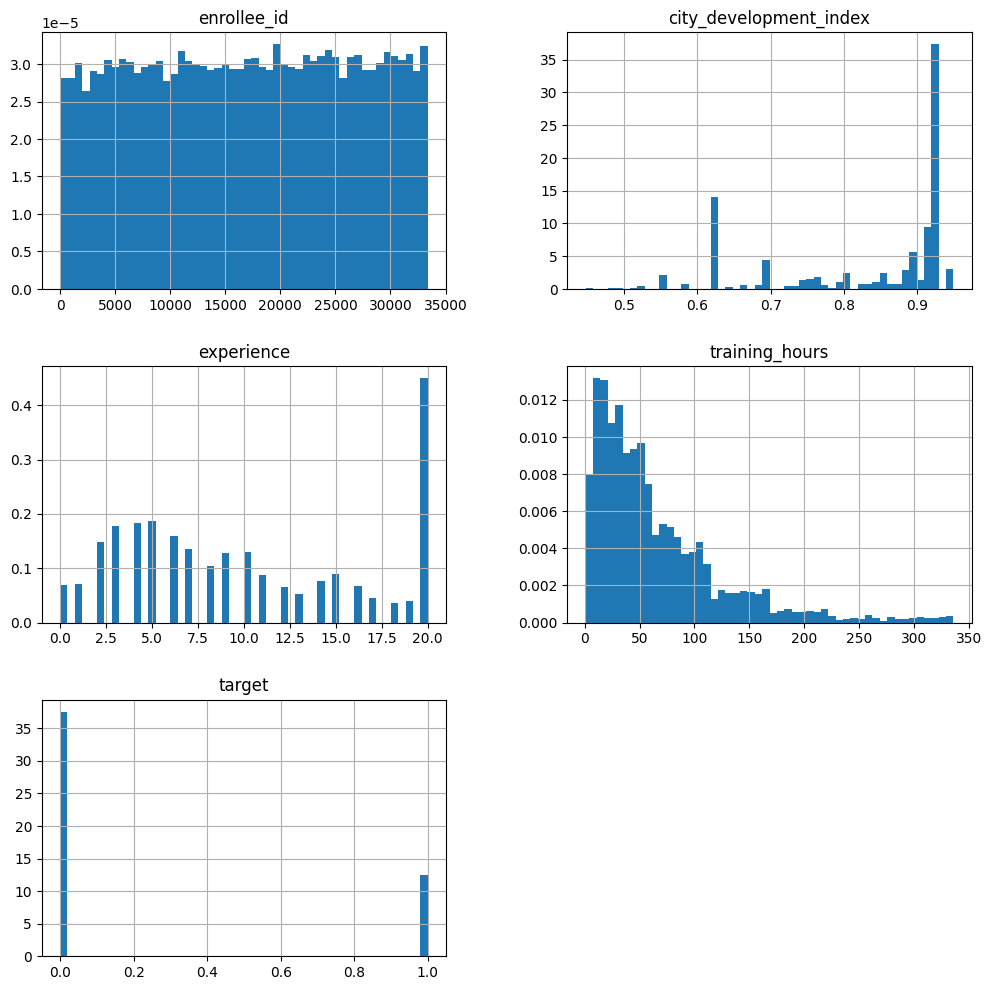

In [15]:
# Drawing histogram plot over the old data -> This is only for numerical data type
data.hist(bins=50,density=True,figsize=(12,12))
plt.show()

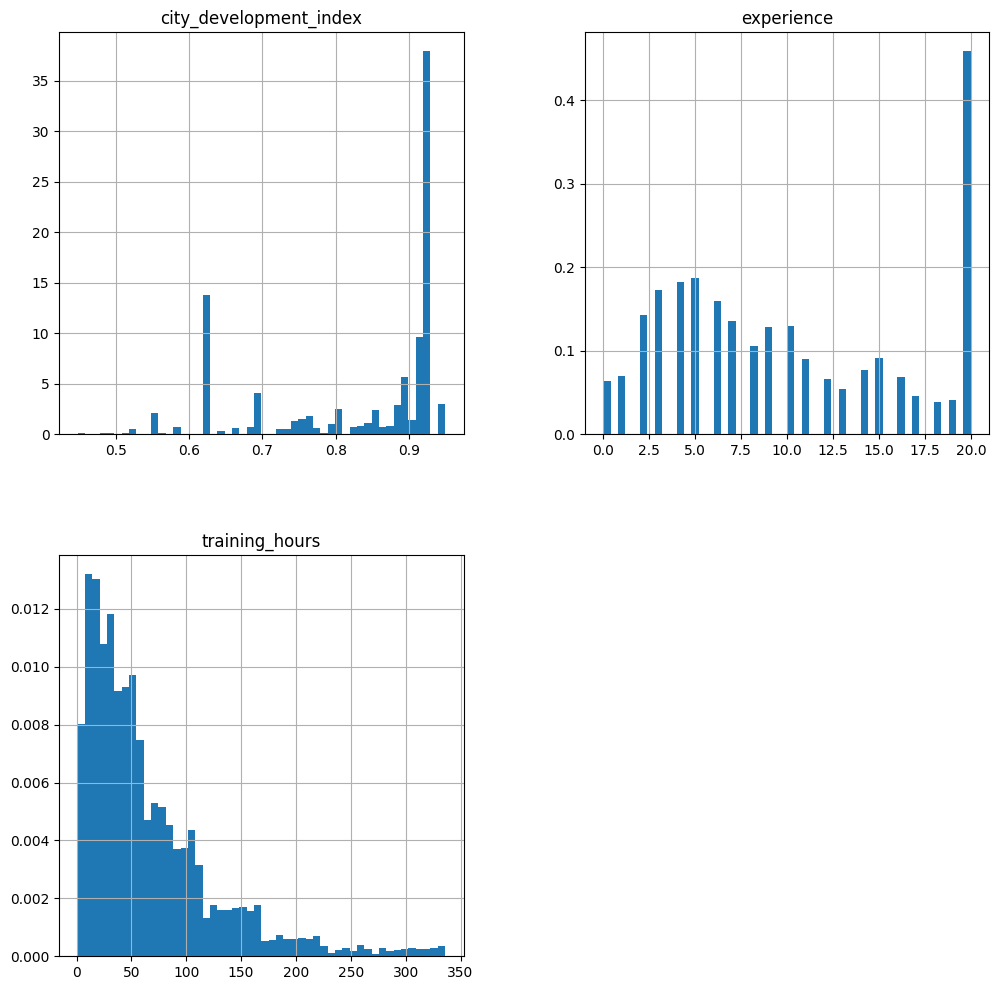

In [16]:
# drawing histplot over new data
new_data.hist(bins=50,density=True,figsize=(12,12))
plt.show()

<Axes: >

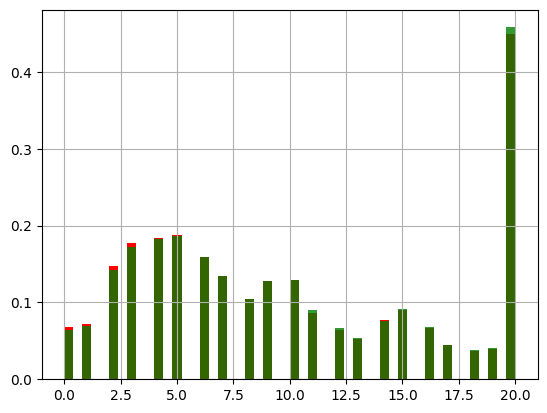

In [17]:
# drawing both hist plot in the same graph
fig = plt.figure()
ax = fig.add_subplot(111)  # it form grid(1*1 and last one is start index form 1)

# original data
data['experience'].hist(bins=50,ax=ax,density=True,color='red')

# data after CCA
new_data['experience'].hist(bins=50,ax=ax,color='green',density=True,alpha=0.8)

<Axes: >

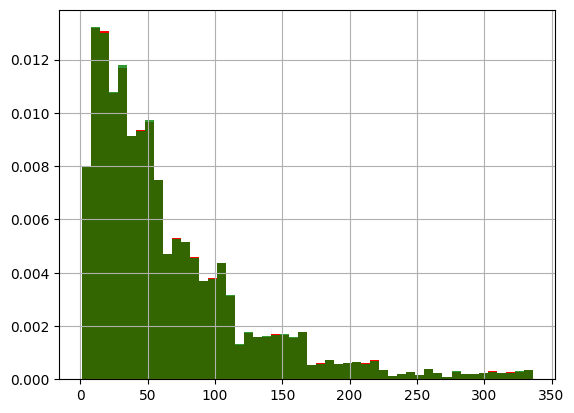

In [18]:
# drawing both hist plot in the same graph
fig = plt.figure()
ax = fig.add_subplot(111)  # it form grid(1*1 and last one is start index form 1)

# original data
data['training_hours'].hist(bins=50,ax=ax,density=True,color='red')

# data after CCA
new_data['training_hours'].hist(bins=50,ax=ax,color='green',density=True,alpha=0.8)

<Axes: >

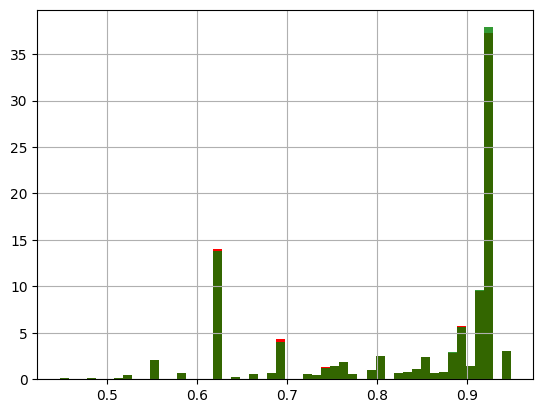

In [19]:
# drawing both hist plot in the same graph
fig = plt.figure()
ax = fig.add_subplot(111)  # it form grid(1*1 and last one is start index form 1)

# original data
data['city_development_index'].hist(bins=50,ax=ax,density=True,color='red')

# data after CCA
new_data['city_development_index'].hist(bins=50,ax=ax,color='green',density=True,alpha=0.8)

<Axes: ylabel='Density'>

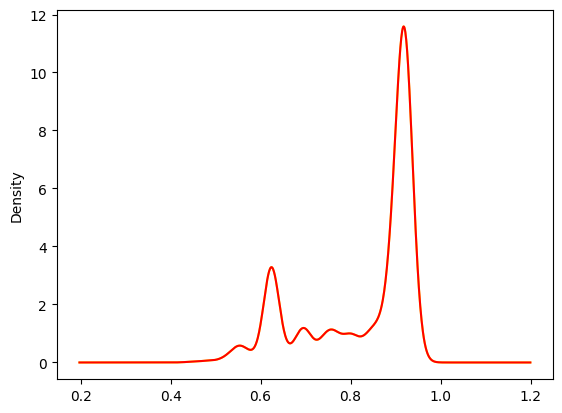

In [20]:
# density plot before and afer CCA 
fig = plt.figure()
ax = fig.add_subplot(111)

# old data
data['city_development_index'].plot.density(color='yellow')

# new_data
data['city_development_index'].plot.density(color='red')

<Axes: ylabel='Density'>

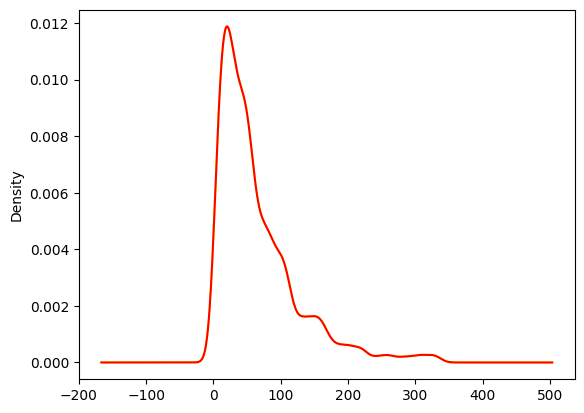

In [21]:
# density plot before and afer CCA 
fig = plt.figure()
ax = fig.add_subplot(111)

# old data
data['training_hours'].plot.density(color='yellow')

# new_data
data['training_hours'].plot.density(color='red')

<Axes: ylabel='Density'>

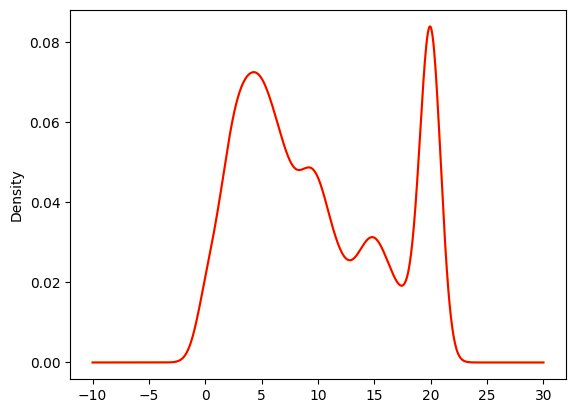

In [22]:
# density plot before and afer CCA 
fig = plt.figure()
ax = fig.add_subplot(111)

# old data
data['experience'].plot.density(color='yellow')

# new_data
data['experience'].plot.density(color='red')

In [24]:
data.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [39]:
# determing the percentage before and after applying CCA
temp = pd.concat([
    # percentage of observing per category, original data
    data['enrolled_university'].value_counts()/ len(data), # it is the ratio of notnull_data to total data
    # percentage of observing per categority, of new_data
    new_data['enrolled_university'].value_counts()/ len(new_data)
],axis=1)

temp.columns = ['original','before']
temp

,original,before
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [40]:
# determing the percentage before and after applying CCA
edu = pd.concat([
    # percentage of observing per category, original data
    data['education_level'].value_counts()/ len(data),
    # percentage of observing per categority, of new_data
    new_data['education_level'].value_counts()/ len(new_data)
],axis=1)

edu.columns = ['original','before']
edu

,original,before
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
